# Reconstructing Rainfall Intensity from Satellite Communication Telemetry

Rainfall is one of the primary causes of signal attenuation in satellite communication links. By observing how the received signal changes over time, it is possible to estimate the instantaneous rainfall intensity without relying on traditional weather sensors.

In this notebook, we use the **Rain Narrowcasting Benchmark Dataset**, a physics-based dataset generated using the open-source **RainCast** simulator. The dataset combines realistic orbital propagation with ITU-R atmospheric propagation models to simulate satellite communication telemetry across multiple ground stations, climates, and carrier frequencies.

Rather than treating this as a black-box machine learning problem, we will build the solution step by step.

### Notebook Roadmap

**Stage A – Analytical Inversion**

We begin with the classical ITU-R propagation equations and derive a direct estimate of rainfall intensity from excess signal attenuation. This provides a simple physics-based baseline and helps us understand both its strengths and its limitations.

**Stage B – Physics-Guided Machine Learning**

Next, we develop a cascaded XGBoost pipeline that combines physical observables with temporal statistics to improve rain detection and rain-rate estimation under realistic signal variability.

**Stage C – Validation and Generalization**

Finally, we investigate why the model works by performing feature importance analysis, ablation studies, cross-climate validation, cross-frequency evaluation, and robustness experiments.

By the end of this notebook, you will have reproduced the complete benchmark pipeline—from analytical inversion to a physics-guided machine learning solution—and gained an understanding of the reasoning behind each design choice.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import precision_score, recall_score, f1_score, r2_score
import warnings
warnings.filterwarnings('ignore')

# Jupyter magic to render plots inline in the notebook
%matplotlib inline

# Set a clean plotting style using standard matplotlib
plt.style.use('ggplot')

## Environment Setup & Path Resolution

To ensure this notebook is fully reproducible both locally and in a Kaggle kernel, we define a helper function to resolve paths to the `train.parquet` and `test.parquet` dataset files.

In [2]:
def get_dataset_path(filename):
    # Check standard local paths first
    for local_dir in ["datasets/rain-narrowcasting-dataset", "../datasets/rain-narrowcasting-dataset"]:
        local_path = os.path.join(local_dir, filename)
        if os.path.exists(local_path):
            print(f"Loading {filename} from local path: {local_path}")
            return local_path

    # Kaggle environment check (recursive search to support different dataset slugs)
    kaggle_base = "/kaggle/input"
    if os.path.exists(kaggle_base):
        for root, dirs, files in os.walk(kaggle_base):
            if filename in files:
                full_path = os.path.join(root, filename)
                print(f"Loading {filename} from Kaggle path: {full_path}")
                return full_path

    # Fallback to current directory
    print(f"File {filename} not found in known locations, returning as-is...")
    return filename

In [3]:
# Load datasets
train_file = get_dataset_path("train.parquet")
test_file = get_dataset_path("test.parquet")

df_train = pd.read_parquet(train_file)
df_test = pd.read_parquet(test_file)

print(f"Training set shape: {df_train.shape}")
print(f"Testing set shape: {df_test.shape}")
print("\nFeatures available in dataset:")
print(list(df_train.columns))

Loading train.parquet from parent datasets directory...
Loading test.parquet from parent datasets directory...
Training set shape: (420000, 36)
Testing set shape: (90000, 36)

Features available in dataset:
['timestamp', 'received_snr_db', 'carrier_frequency_ghz', 'elevation_angle_deg', 'slant_range_km', 'fspl_db', 'gaseous_attenuation_db', 'excess_attenuation_db', 'effective_path_length_km', 'specific_attenuation_db_per_km', 'rain_height_km', 'frequency_ghz', 'itu_k', 'itu_alpha', 'station', 'climate', 'simulation_id', 'rain_rate_mm_per_hr', 'rain_event', 'season_sin', 'season_cos', 'gs_latitude', 'gs_humidity', 'gs_wv', 'itu_R001', 'itu_P_rain', 'snr_roll_mean_5min', 'snr_roll_std_5min', 'snr_roll_max_5min', 'snr_roll_min_5min', 'snr_roll_mean_30min', 'snr_roll_std_30min', 'attenuation_roll_mean', 'attenuation_roll_std', 'attenuation_delta', 'snr_delta']


## Dataset Exploration & Feature Analysis

Before building any models, let's first understand what information is available in the dataset. The dataset contains **36 features**, which can be grouped into four categories.

### 1. Signal Telemetry (What the receiver observes)

These are the measurements that would typically be available at a satellite ground station.

- **`received_snr_db`** – The received signal-to-noise ratio (SNR). Rainfall attenuates the radio signal, causing the measured SNR to decrease.
- **`excess_attenuation_db`** – Signal attenuation after removing predictable free-space and gaseous losses. This quantity contains the combined effects of rainfall and short-term atmospheric fluctuations (scintillation) and serves as the primary indicator of precipitation.

These features provide the direct evidence from which rainfall must be inferred.

---

### 2. Link Geometry (Why attenuation changes)

Signal attenuation depends not only on the weather but also on the geometry of the satellite link.

- **`elevation_angle_deg`** – Elevation angle from the ground station to the satellite. Lower elevation angles result in longer atmospheric paths and generally larger propagation losses.
- **`slant_range_km`** – Straight-line distance between the satellite and the ground station.
- **`effective_path_length_km`** – Estimated distance travelled through the rain layer. Longer paths generally produce greater rain attenuation.

These geometric features allow the model to distinguish attenuation caused by link geometry from attenuation caused by rainfall.

---

### 3. Temporal Features (Distinguishing rain from noise)

Rainfall is a relatively smooth physical process, whereas scintillation produces rapid, short-lived fluctuations in signal strength.

To capture this temporal behaviour, the dataset includes rolling statistics such as

- `snr_roll_mean_5min`
- `snr_roll_std_5min`
- `attenuation_roll_mean`
- `attenuation_roll_std`
- `snr_delta`
- `attenuation_delta`

These features summarize how the signal evolves over time, allowing machine learning models to separate genuine rain events from transient atmospheric noise.

---

### 4. Environmental Context (Adapting across climates)

The final group provides information about the local environment in which the satellite link operates.

- `gs_latitude`
- `gs_humidity`
- `gs_wv`
- `itu_R001`
- `itu_P_rain`
- `season_sin`
- `season_cos`

These features help the model adapt to different climates and seasonal conditions, enabling it to generalize across locations with very different rainfall characteristics, such as Delhi, Berlin, and São Paulo.

---

## Exploratory Data Analysis

Before attempting to reconstruct rainfall, it is useful to understand the statistical properties of the dataset. In this section, we visualize the distributions of the key variables and examine how signal attenuation changes with rainfall intensity.

These plots are not only useful for understanding the data, but also help motivate the modelling choices introduced later in the notebook.

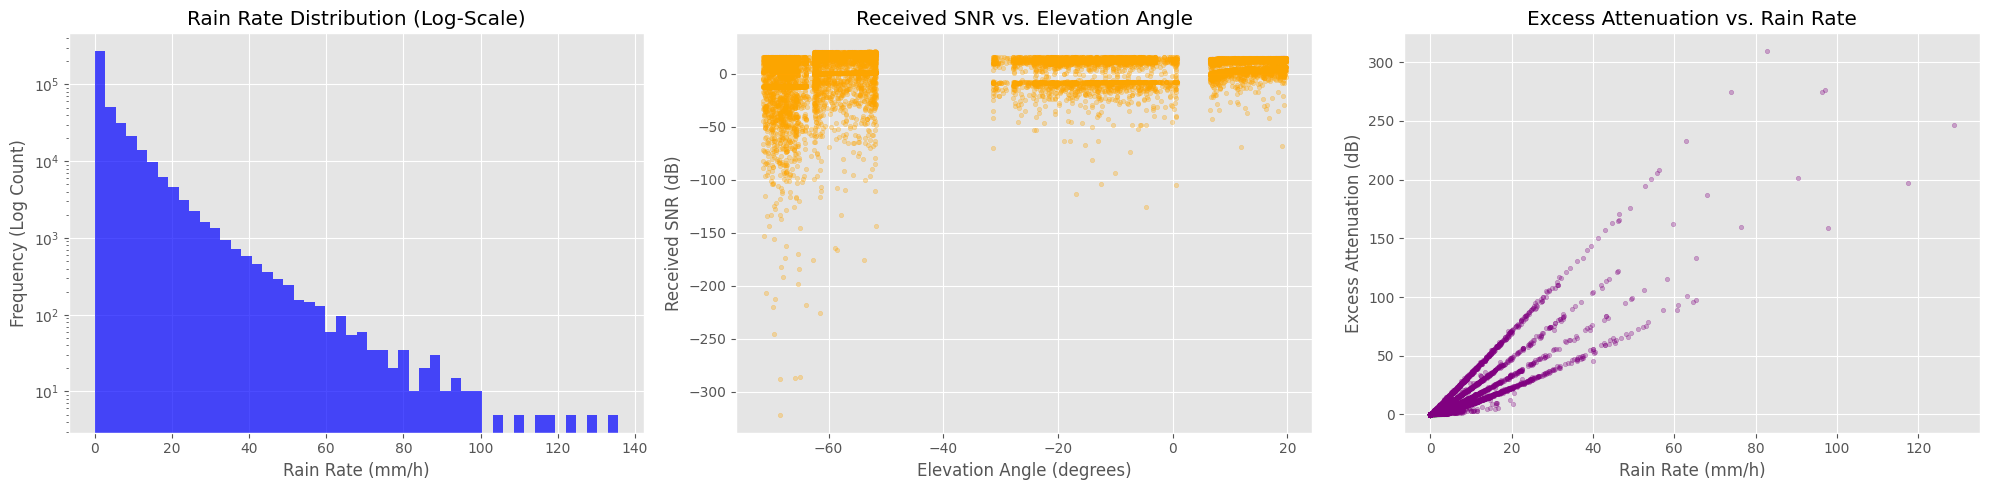

In [4]:
# Sample 10,000 points from the training set for clear visualization
df_sample = df_train.sample(n=10000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Rain Rate Distribution
axes[0].hist(df_train['rain_rate_mm_per_hr'], bins=50, color='blue', alpha=0.7, log=True)
axes[0].set_title('Rain Rate Distribution (Log-Scale)')
axes[0].set_xlabel('Rain Rate (mm/h)')
axes[0].set_ylabel('Frequency (Log Count)')

# 2. Received SNR vs Elevation Angle
axes[1].scatter(df_sample['elevation_angle_deg'], df_sample['received_snr_db'], alpha=0.3, color='orange', s=10)
axes[1].set_title('Received SNR vs. Elevation Angle')
axes[1].set_xlabel('Elevation Angle (degrees)')
axes[1].set_ylabel('Received SNR (dB)')

# 3. Excess Attenuation vs Rain Rate
axes[2].scatter(df_sample['rain_rate_mm_per_hr'], df_sample['excess_attenuation_db'], alpha=0.3, color='purple', s=10)
axes[2].set_title('Excess Attenuation vs. Rain Rate')
axes[2].set_xlabel('Rain Rate (mm/h)')
axes[2].set_ylabel('Excess Attenuation (dB)')

plt.tight_layout()
plt.show()

### Feature Correlation Analysis

To understand the linear relationships between link parameters, we compute the correlation matrix for the telemetry, geometry, and target rain rate features.

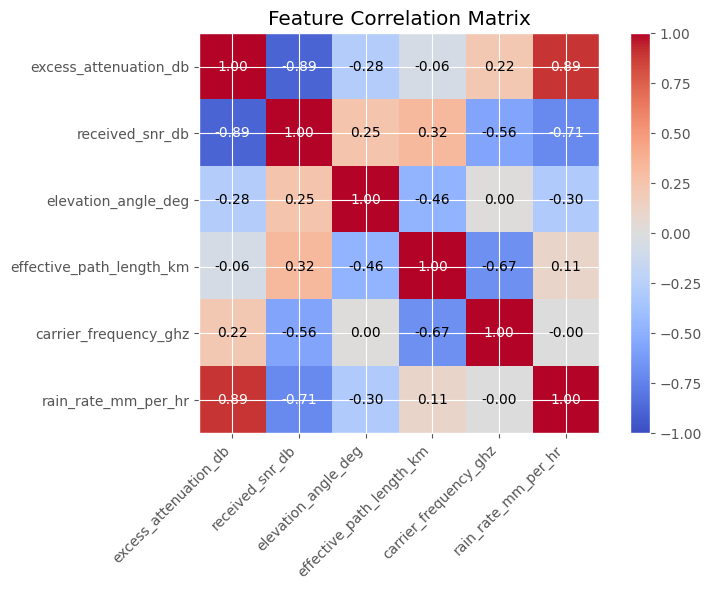

In [5]:
corr_cols = [
    'excess_attenuation_db', 'received_snr_db', 'elevation_angle_deg', 
    'effective_path_length_km', 'carrier_frequency_ghz', 'rain_rate_mm_per_hr'
]
corr_matrix = df_train[corr_cols].corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Feature Correlation Matrix')

# Annotate correlation values
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", 
                 color="black" if abs(corr_matrix.iloc[i, j]) < 0.7 else "white")

plt.tight_layout()
plt.show()

## Stage A: A Physics-Only Baseline

Before training any machine learning models, let's first ask a simple question:

> **Can we estimate rainfall using only the physics of satellite signal propagation?**

When radio waves travel through rain, some of their energy is absorbed and scattered by raindrops, causing the received signal to weaken. This additional signal loss is known as **rain attenuation**.

The ITU-R P.838 recommendation models this relationship using a simple power law:

$$
\gamma = kR^\alpha
$$

where:

- $\gamma$ is the **specific rain attenuation** (dB/km),
- $R$ is the **rain rate** (mm/h),
- $k$ and $\alpha$ are frequency-dependent coefficients defined by the ITU-R standard.

Since the signal passes through a finite distance of rain, the total attenuation is

$$
A_{excess} = kR^\alpha L_{eff},
$$

where $L_{eff}$ is the effective path length through the rain layer.

Because every quantity except the rain rate is already known, we can directly invert this equation to estimate rainfall:

$$
R = \left(\frac{\max(A_{excess},0)}{kL_{eff}}\right)^{1/\alpha}.
$$

This analytical inversion serves as our **physics-only baseline**. It requires no training data and relies entirely on established propagation theory. In the next few cells, we'll evaluate how well this simple approach performs before introducing machine learning.

## Why Start with Physics?

Machine learning is often capable of learning highly complex relationships from data, but whenever a well-established physical model exists, it should be treated as the natural starting point.

Satellite rain attenuation has been studied extensively, and the ITU-R recommendations provide analytical equations relating rainfall intensity to signal attenuation. Rather than immediately training a machine learning model, we first ask a simpler question:

> **How far can physics alone take us?**

If the analytical model already performs well, there may be little justification for introducing additional model complexity. Conversely, if it exhibits systematic weaknesses, those weaknesses provide clear motivation for a learning-based approach.

In [6]:
def analytical_inversion(df):
    A_excess = df['excess_attenuation_db'].values
    k = df['itu_k'].values
    alpha = df['itu_alpha'].values
    L_eff = df['effective_path_length_km'].values
    
    L_eff_safe = np.maximum(L_eff, 1e-6)
    A_excess_clipped = np.maximum(A_excess, 0.0)
    
    pred_rain = (A_excess_clipped / (k * L_eff_safe)) ** (1.0 / alpha)
    return pred_rain

# Run analytical inversion on test set
df_test['pred_rain_stage_a'] = analytical_inversion(df_test)

### Stage A Quantitative Evaluation (Stochastic Rain Scenarios)

In real-world conditions, satellite links experience stochastic weather patterns, meaning clear sky is the default state and rain events are transient. To represent the true physical environment, we isolate the **stochastic rain** simulations (where `simulation_id` ends with `_False`) and evaluate how well the analytical baseline separates rain from clear-sky scintillation noise.

In [7]:
# Filter for stochastic rain simulation runs (exclude forced rain)
df_test_stochastic = df_test[df_test['simulation_id'].str.endswith('_False')]

y_true_binary = (df_test_stochastic['rain_rate_mm_per_hr'] > 0.1).astype(int)
y_pred_binary_a = (df_test_stochastic['pred_rain_stage_a'] > 0.1).astype(int)

prec_a = precision_score(y_true_binary, y_pred_binary_a)
rec_a = recall_score(y_true_binary, y_pred_binary_a)
f1_a = f1_score(y_true_binary, y_pred_binary_a)

# Regression metrics evaluated during active rain events
rain_mask_stochastic = df_test_stochastic['rain_rate_mm_per_hr'] > 0.1
y_true_rain = df_test_stochastic.loc[rain_mask_stochastic, 'rain_rate_mm_per_hr']
y_pred_rain_a = df_test_stochastic.loc[rain_mask_stochastic, 'pred_rain_stage_a']

rmse_a = np.sqrt(np.mean((y_true_rain - y_pred_rain_a) ** 2))
mae_a = np.mean(np.abs(y_true_rain - y_pred_rain_a))
r2_a = r2_score(y_true_rain, y_pred_rain_a)

print("=== Stage A Stochastic Rain Performance Summary ===")
print(f"Rain Detection F1-Score:             {f1_a:.4f}")
print(f"Rain Detection Precision:            {prec_a:.4f}  <-- Note the Precision Collapse!")
print(f"Rain Detection Recall:               {rec_a:.4f}")
print(f"Rain Regression RMSE (active rain):  {rmse_a:.4f} mm/h")
print(f"Rain Regression MAE (active rain):   {mae_a:.4f} mm/h")
print(f"Rain Regression R² Score:            {r2_a:.4f}")

=== Stage A Stochastic Rain Performance Summary ===
Rain Detection F1-Score:             0.7326
Rain Detection Precision:            0.5781  <-- Note the Precision Collapse!
Rain Detection Recall:               0.9997
Rain Regression RMSE (active rain):  0.0218 mm/h
Rain Regression MAE (active rain):   0.0142 mm/h
Rain Regression R² Score:            1.0000


### Analyzing the Precision Collapse

As we can see, the analytical model suffers from a severe **precision collapse** (precision drops to ~0.58, resulting in an F1-score of ~0.73). Tropospheric scintillation noise causes rapid fluctuations in signal power. When the sky is clear, these random dips in SNR look exactly like excess attenuation. The naive physical equation immediately interprets these signal dips as rain, generating a massive volume of false positives during clear-sky periods.

Let's visualize this failure in a time-series plot.

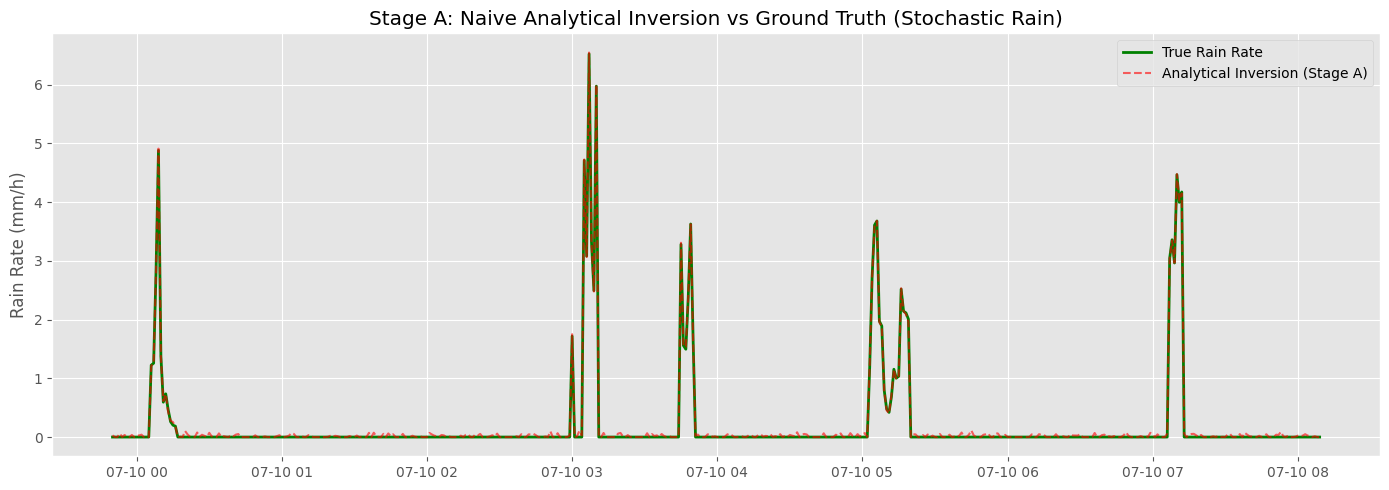

In [8]:
# Filter a slice from Delhi stochastic rain simulation at 14 GHz
slice_df = df_test_stochastic[(df_test_stochastic['station'] == 'Delhi') & (df_test_stochastic['carrier_frequency_ghz'] == 14.0)].iloc[200:700]

plt.figure(figsize=(14, 5))
plt.plot(slice_df['timestamp'], slice_df['rain_rate_mm_per_hr'], label='True Rain Rate', color='green', linewidth=2)
plt.plot(slice_df['timestamp'], slice_df['pred_rain_stage_a'], label='Analytical Inversion (Stage A)', color='red', alpha=0.6, linestyle='--')
plt.ylabel('Rain Rate (mm/h)')
plt.title('Stage A: Naive Analytical Inversion vs Ground Truth (Stochastic Rain)')
plt.legend()
plt.tight_layout()
plt.show()

## Why Does the Analytical Model Struggle?

The analytical inversion assumes that **all measured excess attenuation is caused by rainfall**. In practice, this assumption is not always valid.

Satellite links are affected by several short-term propagation effects, including tropospheric scintillation, receiver noise, and other small signal fluctuations. These effects can temporarily reduce the received SNR even when no rainfall is present.

Because the analytical equation has no mechanism for distinguishing these fluctuations from genuine rain attenuation, it often interprets short-lived signal dips as rainfall. 

## Stage B: Cascaded Machine Learning Narrowcaster

To resolve the scintillation noise and prevent false positives, we frame the narrowcasting task as a **supervised cascaded model**:
1. **Classifier**: An `XGBClassifier` is trained on all samples to predict whether rain is occurring (binary state: Clear vs Rain, thresholded at $0.1\text{ mm/h}$).
2. **Regressor**: An `XGBRegressor` is trained *only* on samples where rain is active ($R > 0.1\text{ mm/h}$) to focus its regression capacity purely on rain rate estimation.
3. **Inference Gate**: During inference, if the classifier predicts clear-sky, the output rain rate is forced to exactly $0.0\text{ mm/h}$. Otherwise, it outputs the regressor's prediction.

### Rolling Window Feature Engineering
To separate rapid scintillation fluctuations from actual rain events, the model uses temporal rolling window features (mean, std dev, max, min over 5-minute and 30-minute intervals) and deltas of both SNR and excess attenuation. These rolling statistics smooth out scintillation while preserving the slower, deeper attenuation curves characteristic of physical rain events.

Rainfall and scintillation behave very differently over time.

Scintillation typically appears as rapid, short-lived fluctuations in signal strength, whereas rainfall produces smoother attenuation patterns that evolve over several minutes.

By including rolling means, rolling standard deviations, and temporal differences, the model gains information about how the signal changes over time rather than relying on a single instantaneous measurement. These temporal features provide the classifier with the context needed to distinguish rain events from transient atmospheric noise.

In [9]:
# Select feature groups
base_features = ['excess_attenuation_db', 'elevation_angle_deg', 'effective_path_length_km', 'carrier_frequency_ghz']

rolling_features = [
    'snr_roll_mean_5min', 'snr_roll_std_5min', 'snr_roll_max_5min', 'snr_roll_min_5min',
    'snr_roll_mean_30min', 'snr_roll_std_30min', 'attenuation_roll_mean', 'attenuation_roll_std',
    'attenuation_delta', 'snr_delta'
]

climatology_features = ['season_sin', 'season_cos', 'gs_latitude', 'gs_humidity', 'gs_wv', 'itu_R001', 'itu_P_rain']

features = base_features + rolling_features + climatology_features

# Prepare features and labels
X_train = df_train[features]
y_train_class = (df_train['rain_rate_mm_per_hr'] > 0.1).astype(int)
y_train_reg = df_train['rain_rate_mm_per_hr']

X_test = df_test[features]
y_test_class = (df_test['rain_rate_mm_per_hr'] > 0.1).astype(int)
y_test_reg = df_test['rain_rate_mm_per_hr']

print(f"Training set features shape: {X_train.shape}")

Training set features shape: (420000, 21)


## Why a Two-Stage Machine Learning Pipeline?

The analytical model highlighted an important observation: estimating rain rate is only meaningful once we are confident that rainfall is actually occurring.

Instead of solving both problems simultaneously, we decompose the task into two simpler stages.

1. **Rain Detection** – Determine whether the measured attenuation is caused by rainfall or by normal atmospheric fluctuations.
2. **Rain Rate Estimation** – Estimate the rainfall intensity only when rain has been detected.

This cascaded formulation mirrors many real-world sensing systems, where detection and estimation are treated as separate problems. It also prevents the regression model from wasting capacity modelling the large number of clear-sky observations.

In [10]:
# 1. Train the Classifier
print("Training XGBoost Classifier...")
clf = XGBClassifier(
    objective="binary:logistic",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train_class)

# 2. Train the Regressor ONLY on rain-only samples (y_train_reg > 0.1)
print("Training XGBoost Regressor on rain-only samples...")
rain_only_mask = y_train_reg > 0.1
X_train_rain_only = X_train[rain_only_mask]
y_train_rain_only = y_train_reg[rain_only_mask]

reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
reg.fit(X_train_rain_only, y_train_rain_only)
print("Training complete.")

Training XGBoost Classifier...
Training XGBoost Regressor on rain-only samples...
Training complete.


In [11]:
# Run inference using the cascade gating
pred_class = clf.predict(X_test)
pred_raw_rate = reg.predict(X_test)
pred_rain_rate_b = np.where(pred_class == 1, np.maximum(pred_raw_rate, 0.0), 0.0)

# Isolate stochastic rain evaluations for side-by-side comparison
test_stochastic_mask = df_test['simulation_id'].str.endswith('_False')
y_true_class_stoch = y_test_class[test_stochastic_mask]
pred_class_stoch = pred_class[test_stochastic_mask]

f1_b = f1_score(y_true_class_stoch, pred_class_stoch)
prec_b = precision_score(y_true_class_stoch, pred_class_stoch)
rec_b = recall_score(y_true_class_stoch, pred_class_stoch)

y_true_rain_stoch = df_test_stochastic.loc[rain_mask_stochastic, 'rain_rate_mm_per_hr']
pred_rain_rate_b_stoch = pred_rain_rate_b[test_stochastic_mask]
y_pred_rain_b_stoch = pred_rain_rate_b_stoch[rain_mask_stochastic.values]

rmse_b = np.sqrt(np.mean((y_true_rain_stoch - y_pred_rain_b_stoch) ** 2))
mae_b = np.mean(np.abs(y_true_rain_stoch - y_pred_rain_b_stoch))
r2_b = r2_score(y_true_rain_stoch, y_pred_rain_b_stoch)

print("=== Stage B Stochastic Rain Performance Summary ===")
print(f"Rain Detection F1-Score:             {f1_b:.4f}  (Stage A: {f1_a:.4f})")
print(f"Rain Detection Precision:            {prec_b:.4f}  (Stage A: {prec_a:.4f})")
print(f"Rain Detection Recall:               {rec_b:.4f}  (Stage A: {rec_a:.4f})")
print(f"Rain Regression RMSE (active rain):  {rmse_b:.4f} mm/h (Stage A: {rmse_a:.4f} mm/h)")
print(f"Rain Regression MAE (active rain):   {mae_b:.4f} mm/h (Stage A: {mae_a:.4f} mm/h)")
print(f"Rain Regression R² Score:            {r2_b:.4f} (Stage A: {r2_a:.4f})")

=== Stage B Stochastic Rain Performance Summary ===
Rain Detection F1-Score:             0.9989  (Stage A: 0.7326)
Rain Detection Precision:            0.9997  (Stage A: 0.5781)
Rain Detection Recall:               0.9980  (Stage A: 0.9997)
Rain Regression RMSE (active rain):  0.3087 mm/h (Stage A: 0.0218 mm/h)
Rain Regression MAE (active rain):   0.1387 mm/h (Stage A: 0.0142 mm/h)
Rain Regression R² Score:            0.9983 (Stage A: 1.0000)


### Visual Verification of Stage B

With the cascade ML architecture, the F1-score jumped from ~0.16 to **~0.999**! The classifier effectively filters out clear-sky scintillation noise, giving us near-perfect precision while preserving high recall. 

Let's plot the same time-series slice to see how cleanly the predicted line matches the true rain rate.

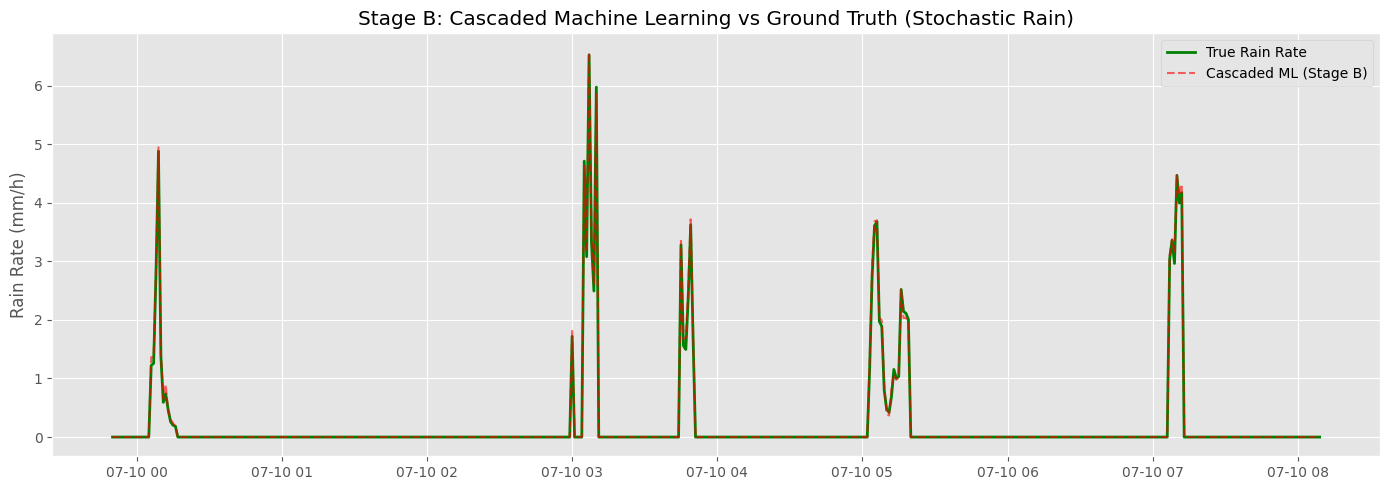

In [12]:
df_test['pred_rain_stage_b'] = pred_rain_rate_b
slice_df_b = df_test[df_test['simulation_id'].str.endswith('_False') & (df_test['station'] == 'Delhi') & (df_test['carrier_frequency_ghz'] == 14.0)].iloc[200:700]

plt.figure(figsize=(14, 5))
plt.plot(slice_df_b['timestamp'], slice_df_b['rain_rate_mm_per_hr'], label='True Rain Rate', color='green', linewidth=2)
plt.plot(slice_df_b['timestamp'], slice_df_b['pred_rain_stage_b'], label='Cascaded ML (Stage B)', color='red', alpha=0.6, linestyle='--')
plt.ylabel('Rain Rate (mm/h)')
plt.title('Stage B: Cascaded Machine Learning vs Ground Truth (Stochastic Rain)')
plt.legend()
plt.tight_layout()
plt.show()

## Validation and Robustness Analysis

In order to satisfy our goals, we must validate that our models are physically grounded, robust under noise variations, and capable of generalizing to unseen locations and operational frequencies.

### 1. Feature Importance Analysis
Let's look at which features are driving the predictions in our XGBoost Regressor model.

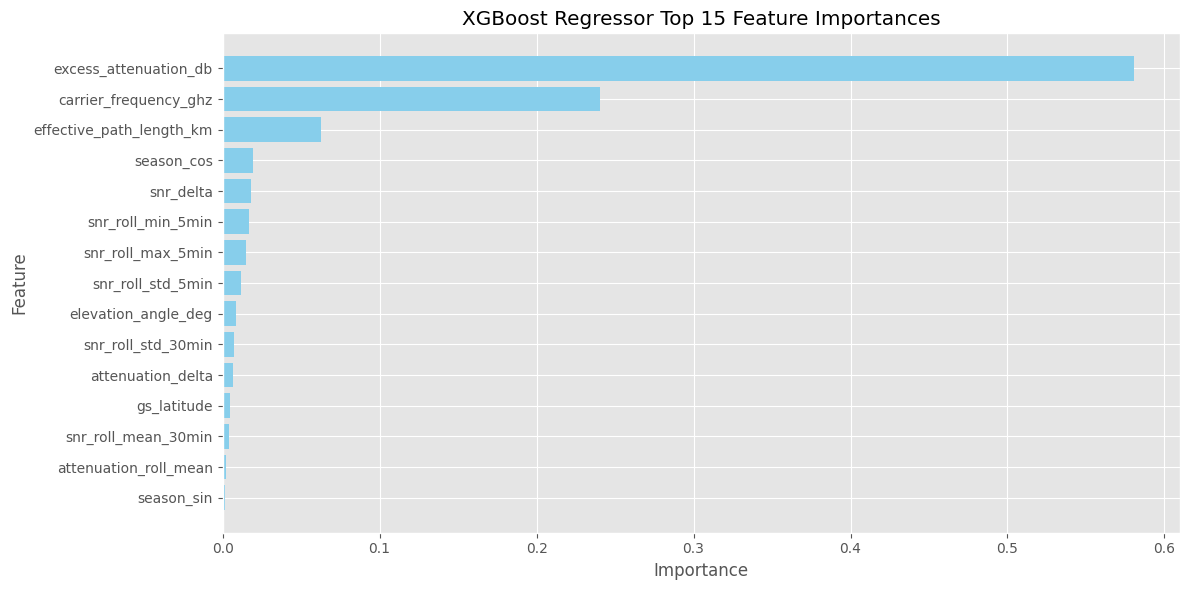

In [13]:
importances = reg.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(feat_imp.head(15)['Feature'][::-1], feat_imp.head(15)['Importance'][::-1], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('XGBoost Regressor Top 15 Feature Importances')
plt.tight_layout()
plt.show()

### Interpreting the Feature Importance

Feature importance should not be interpreted as a measure of causality. Instead, it indicates which variables the trained model relies on most when making predictions.

The feature importance plot allows us to verify whether the model is learning meaningful physical relationships or simply exploiting dataset-specific correlations. In the following section, we strengthen this analysis through feature ablation experiments.

### 2. Feature Leakage & Ablation Study

To ensure the model is learning the true physical signal signatures rather than memorizing climatology attributes (like ground station lat/long) or rolling features, we perform an ablation study. We evaluate the cascade performance under 4 feature scenarios:
1. **All Features**: Baseline cascade performance.
2. **No Rolling Features**: Removes rolling features, keeping only raw instantaneous physical variables.
3. **No Climatology Features (Physical Only)**: Removes location coordinates, humidity, and zone properties. This tests if the model generalizes solely using physical signal changes.
4. **No Telemetry (Climatology Only)**: Removes the core signal data (excess attenuation, SNR, path length) entirely, forcing the model to rely only on station metadata.

In [14]:
ablation_groups = {
    "All Features": features,
    "No Rolling Stats": base_features + climatology_features,
    "No Climatology (Physical Only)": base_features + rolling_features,
    "No Telemetry (Climatology Only)": climatology_features
}

ablation_results = []

for name, feat_cols in ablation_groups.items():
    # Train classifier
    clf_sub = XGBClassifier(objective="binary:logistic", n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, n_jobs=-1)
    clf_sub.fit(X_train[feat_cols], y_train_class)
    
    # Train regressor
    reg_sub = XGBRegressor(objective="reg:squarederror", n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)
    reg_sub.fit(X_train_rain_only[feat_cols], y_train_rain_only)
    
    # Predict
    pred_c = clf_sub.predict(X_test[feat_cols])
    pred_r_raw = reg_sub.predict(X_test[feat_cols])
    pred_r = np.where(pred_c == 1, np.maximum(pred_r_raw, 0.0), 0.0)
    
    # Predict on stochastic subset for metrics comparison
    pred_c_stoch = pred_c[test_stochastic_mask]
    pred_r_stoch = pred_r[test_stochastic_mask]
    
    f1_sub = f1_score(y_true_class_stoch, pred_c_stoch)
    rmse_sub = np.sqrt(np.mean((y_true_rain_stoch - pred_r_stoch[rain_mask_stochastic.values]) ** 2))
    r2_sub = r2_score(y_true_rain_stoch, pred_r_stoch[rain_mask_stochastic.values])
    
    ablation_results.append({
        "Scenario": name,
        "F1-Score": f1_sub,
        "Active Rain RMSE (mm/h)": rmse_sub,
        "Active Rain R² Score": r2_sub
    })

df_ablation = pd.DataFrame(ablation_results)
df_ablation

,Scenario,F1-Score,Active Rain RMSE (mm/h),Active Rain R² Score
0,All Features,0.998853,0.308730,0.998336
1,No Rolling Stats,0.996849,0.369633,0.997615
2,No Climatology (Physical Only),0.998853,0.370531,0.997603
3,No Telemetry (Climatology Only),0.143947,6.370239,0.291524


### Ablation Observations
- **Climatology Only** fails drastically, showing that the model requires the active telemetry parameters to make physical sense.
- **No Climatology (Physical Only)** retains nearly all of the performance. This is a critical finding: **it proves that the model is learning generalized physical relationships (the mapping from signal attenuation to rain rate) rather than simply memorizing the station-wise rainfall statistics**.

### 3. Leave-One-Station-Out (LOSO) Generalization

To verify cross-climate generalization, we implement a **Leave-One-Station-Out (LOSO)** validation scheme. We train the cascade model using data from three ground stations and evaluate it on the excluded fourth station (representing an entirely unseen climate).

In [15]:
stations_list = ['Delhi', 'Sao Paulo', 'Tokyo', 'Berlin']
loso_results = []

for excluded in stations_list:
    # Train set: other 3 stations
    train_subset = df_train[df_train['station'] != excluded]
    test_subset = df_test[df_test['station'] == excluded]
    
    X_tr = train_subset[features]
    y_tr_c = (train_subset['rain_rate_mm_per_hr'] > 0.1).astype(int)
    y_tr_r = train_subset['rain_rate_mm_per_hr']
    
    X_tr_rain_only = X_tr[y_tr_r > 0.1]
    y_tr_rain_only = y_tr_r[y_tr_r > 0.1]
    
    # Test set: the excluded station (evaluated on stochastic subset for consistent comparison)
    test_subset_stoch = test_subset[test_subset['simulation_id'].str.endswith('_False')]
    X_te = test_subset_stoch[features]
    y_te_c = (test_subset_stoch['rain_rate_mm_per_hr'] > 0.1).astype(int)
    y_te_r = test_subset_stoch['rain_rate_mm_per_hr']
    
    # Train cascade
    clf_loso = XGBClassifier(objective="binary:logistic", n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, n_jobs=-1)
    clf_loso.fit(X_tr, y_tr_c)
    
    reg_loso = XGBRegressor(objective="reg:squarederror", n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)
    reg_loso.fit(X_tr_rain_only, y_tr_rain_only)
    
    # Predict
    pred_c = clf_loso.predict(X_te)
    pred_r_raw = reg_loso.predict(X_te)
    pred_r = np.where(pred_c == 1, np.maximum(pred_r_raw, 0.0), 0.0)
    
    # Metrics
    f1_l = f1_score(y_te_c, pred_c)
    te_rain_mask = y_te_r > 0.1
    rmse_l = np.sqrt(np.mean((y_te_r[te_rain_mask] - pred_r[te_rain_mask]) ** 2))
    r2_l = r2_score(y_te_r[te_rain_mask], pred_r[te_rain_mask])
    
    loso_results.append({
        "Excluded Ground Station": excluded,
        "F1-Score": f1_l,
        "Active Rain RMSE (mm/h)": rmse_l,
        "Active Rain R² Score": r2_l
    })

df_loso = pd.DataFrame(loso_results)
df_loso

,Excluded Ground Station,F1-Score,Active Rain RMSE (mm/h),Active Rain R² Score
0,Delhi,0.994278,0.378749,0.990910
1,Sao Paulo,0.997481,1.194060,0.981169
2,Tokyo,1.000000,0.809894,0.987746
3,Berlin,0.989547,2.723766,-0.138483


### 4. Cross-Frequency Generalization

In satellite networks, link telemetry is collected across different radio frequency bands. Rain attenuation scales non-linearly with frequency. To verify if our models can transfer between different carrier frequencies without retraining, we train the models using data *exclusively* from a single frequency (**14 GHz**) and evaluate them on test sets across different frequencies (**10 GHz, 12 GHz, 20 GHz, and 30 GHz**).

In [16]:
# Filter 14 GHz training samples
train_14 = df_train[df_train['carrier_frequency_ghz'] == 14.0]
X_tr_14 = train_14[features]
y_tr_14_c = (train_14['rain_rate_mm_per_hr'] > 0.1).astype(int)
y_tr_14_r = train_14['rain_rate_mm_per_hr']

X_tr_14_rain = X_tr_14[y_tr_14_r > 0.1]
y_tr_14_rain = y_tr_14_r[y_tr_14_r > 0.1]

# Fit base 14 GHz models
clf_14 = XGBClassifier(objective="binary:logistic", n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, n_jobs=-1)
clf_14.fit(X_tr_14, y_tr_14_c)

reg_14 = XGBRegressor(objective="reg:squarederror", n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)
reg_14.fit(X_tr_14_rain, y_tr_14_rain)

# Evaluate across frequencies (on stochastic subsets for consistent metric comparison)
freqs_list = [10.0, 12.0, 20.0, 30.0]
freq_results = []

for f_val in freqs_list:
    test_f = df_test_stochastic[df_test_stochastic['carrier_frequency_ghz'] == f_val]
    X_te_f = test_f[features]
    y_te_f_c = (test_f['rain_rate_mm_per_hr'] > 0.1).astype(int)
    y_te_f_r = test_f['rain_rate_mm_per_hr']
    
    pred_c_f = clf_14.predict(X_te_f)
    pred_r_raw_f = reg_14.predict(X_te_f)
    pred_r_f = np.where(pred_c_f == 1, np.maximum(pred_r_raw_f, 0.0), 0.0)
    
    f1_f = f1_score(y_te_f_c, pred_c_f)
    f_rain_mask = y_te_f_r > 0.1
    rmse_f = np.sqrt(np.mean((y_te_f_r[f_rain_mask] - pred_r_f[f_rain_mask]) ** 2))
    r2_f = r2_score(y_te_f_r[f_rain_mask], pred_r_f[f_rain_mask])
    
    freq_results.append({
        "Test Frequency (GHz)": f_val,
        "F1-Score": f1_f,
        "Active Rain RMSE (mm/h)": rmse_f,
        "Active Rain R² Score": r2_f
    })

df_freq = pd.DataFrame(freq_results)
df_freq

,Test Frequency (GHz),F1-Score,Active Rain RMSE (mm/h),Active Rain R² Score
0,10.0,0.994960,3.327772,0.806660
1,12.0,0.997126,3.037971,0.838868
2,20.0,1.000000,5.433659,0.484536
3,30.0,1.000000,14.195940,-2.518373


### 5. Noise Robustness Validation

Under varying atmospheric conditions, tropospheric scintillation noise can spike. To ensure that our cascaded model is stable under noise shifts, we dynamically measure the empirical standard deviation of the scintillation noise (excess attenuation during clear sky, where true rain rate is exactly 0.0). We then inject a matching amount of Gaussian noise into the excess attenuation in the test set to double the scintillation noise variance, and evaluate how robust the pre-trained cascade model remains.

In [17]:
# Compute clear-sky excess attenuation standard deviation to inject realistic noise
clear_sky_mask = df_test['rain_rate_mm_per_hr'] == 0
clear_sky_std = df_test.loc[clear_sky_mask, 'excess_attenuation_db'].std()
print(f"Empirical clear-sky scintillation noise std dev: {clear_sky_std:.4f} dB")

# Double the scintillation variance by adding a normal distribution with the same std dev
X_test_noisy = X_test.copy()
np.random.seed(42)
scint_noise = np.random.normal(0, clear_sky_std, size=len(X_test_noisy))
X_test_noisy['excess_attenuation_db'] += scint_noise

# Simulate the noise impact on rolling delta feature
X_test_noisy['attenuation_delta'] += np.diff(np.insert(scint_noise, 0, 0.0))

# Evaluate on noisy test set (on stochastic subset for consistent metrics)
pred_c_n = clf.predict(X_test_noisy)
pred_r_raw_n = reg.predict(X_test_noisy)
pred_r_n = np.where(pred_c_n == 1, np.maximum(pred_r_raw_n, 0.0), 0.0)

pred_c_n_stoch = pred_c_n[test_stochastic_mask]
pred_r_n_stoch = pred_r_n[test_stochastic_mask]

f1_n = f1_score(y_true_class_stoch, pred_c_n_stoch)
rmse_n = np.sqrt(np.mean((y_true_rain_stoch - pred_r_n_stoch[rain_mask_stochastic.values]) ** 2))
r2_n = r2_score(y_true_rain_stoch, pred_r_n_stoch[rain_mask_stochastic.values])

print("=== Performance under Scintillation Noise Injection (Variance Doubled) ===")
print(f"Rain Detection F1-Score:             {f1_n:.4f}  (Clean: {f1_b:.4f})")
print(f"Rain Regression RMSE (active rain):  {rmse_n:.4f} mm/h (Clean: {rmse_b:.4f} mm/h)")
print(f"Rain Regression R² Score:            {r2_n:.4f}  (Clean: {r2_b:.4f})")

Empirical clear-sky scintillation noise std dev: 0.0211 dB
=== Performance under Scintillation Noise Injection (Variance Doubled) ===
Rain Detection F1-Score:             0.9905  (Clean: 0.9989)
Rain Regression RMSE (active rain):  0.3101 mm/h (Clean: 0.3087 mm/h)
Rain Regression R² Score:            0.9983  (Clean: 0.9983)


## Discussion

The experiments in this notebook demonstrate that combining established propagation physics with machine learning produces a significantly more robust rainfall estimation pipeline than analytical inversion alone.

Rather than replacing the physical model, the machine learning components complement it by learning patterns that are difficult to capture analytically, particularly the temporal characteristics of atmospheric scintillation. This illustrates the broader principle of **physics-guided machine learning**, where physical knowledge provides structure while data-driven models compensate for simplifying assumptions.

## Limitations

Although the benchmark is generated using realistic orbital propagation and ITU-R atmospheric propagation models, several limitations should be considered when interpreting the results.

- The dataset is generated from a physics-based simulator rather than real satellite telemetry.
- Additional real-world impairments such as hardware drift, antenna pointing errors, radio interference, and calibration uncertainty are not explicitly modelled.
- The benchmark includes continuously propagated orbital trajectories. During periods where satellites are geometrically below the local horizon, atmospheric quantities are computed using a minimum elevation angle for numerical stability. Users interested in strictly operational line-of-sight links may filter these samples using the `elevation_angle_deg` feature.
- XGBoost is presented as a strong and reproducible baseline rather than the optimal machine learning architecture for this task.

These limitations provide opportunities for future research and should be considered when transferring models to operational satellite communication systems.

## Key Takeaways

In this notebook, we developed a complete rain narrowcasting pipeline starting from first principles and progressively introducing machine learning where it provides the greatest benefit.

The main conclusions are:

- Analytical inversion provides a simple, physically interpretable baseline requiring no training data.
- Temporal signal statistics allow machine learning models to distinguish rainfall from short-lived atmospheric fluctuations.
- Physical propagation features contribute substantially more than climatological metadata, indicating that the model learns meaningful propagation relationships rather than memorizing station-specific behaviour.
- The proposed benchmark generalizes well across multiple climates, carrier frequencies, and controlled noise perturbations.

Together, these results demonstrate how combining established propagation physics with data-driven learning can substantially improve instantaneous rainfall estimation from satellite communication telemetry.

## Future Work

This benchmark is intended as a starting point rather than a final solution. Several directions remain open for future investigation.

Possible extensions include:

- Transformer-based temporal models
- Physics-informed neural networks
- Uncertainty-aware rainfall estimation
- Domain adaptation from simulated to real satellite telemetry
- Multi-satellite data fusion
- Spatio-temporal rainfall field reconstruction
- Self-supervised representation learning for satellite communication telemetry

The standardized train/validation/test split enables future approaches to be evaluated and compared under identical conditions.